**PROJET**

In [8]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random

# Partie 1

Question 1 : Génération de profils de vote

Nous générons un vote de référence ainsi que son opposé. Chaque votante est assignée à un groupe en fonction du paramètre de polarisation. Afin d’introduire de la variabilité, nous ajoutons un bruit aléatoire sur les votes en modifiant un certain nombre de positions tiré selon une loi binomiale.

In [9]:
def generation_profile_approbation(n, m, polarisation, p=0.1):

    profile = []
    vote = [np.random.randint(0, 2) for _ in range(m)]
    vote_opp = [1 - x for x in vote]

    if polarisation == 0:
        return [vote.copy() for _ in range(n)]
    
    if polarisation == 1:
        return [vote.copy() for _ in range(n // 2)] + [vote_opp.copy() for _ in range(n // 2)]
    
    # fonction qui prends en argument une liste de vote et modifie aléatoirement un nombre de vote selon une loi binomial avec comme paramètre p
    def ajouter_bruit(base):
        copie = base.copy()
        nb_modifs = np.random.binomial(m, p)
        indices = np.random.choice(m, nb_modifs, replace=False)
        for i in indices:
            copie[i] = 1 - copie[i]
        return copie

    # pour les n électeur on décide de qu'elle "côté de la polarisation" il va être puis on appliquqe ajouter_bruit
    for _ in range(n):
        r = np.random.rand()

        if r < polarisation / 2:
            profile.append(ajouter_bruit(vote_opp))

        elif r < polarisation:
            profile.append(ajouter_bruit(vote))

        else:
            profile.append(vote.copy())

    return profile

Question 2 : Génération de profils de vote avec ordre total. 
  
Nous introduisons un bruit en effectuant des échanges locaux dans le classement. Les positions modifiées sont tirées selon une loi normale centrée au milieu du classement. Ce choix reflète l’hypothèse que les votantes d’un même groupe partagent des préférences similaires concernant les candidates les plus et les moins appréciées, tandis que les désaccords portent davantage sur les candidates intermédiaires.

In [10]:
def generation_profile_ordretotal(n, m, polarisation, p=0.1, scale=1, spread=1):

    # classement de base
    vote = np.random.permutation(m).tolist()
    vote_opp = vote[::-1]

    # cas extrêmes
    if polarisation == 0:
        return [vote.copy() for _ in range(n)]

    if polarisation == 1:
        return [vote.copy() for _ in range(n // 2)] + [vote_opp.copy() for _ in range(n // 2)]

    def ajouter_bruit_ordre(base):
        copie = base.copy()
        nb_modifs = np.random.binomial(m, p)
        for _ in range(nb_modifs):
            # tirage autour du milieu
            i = int(np.random.normal(loc=m // 2, scale=scale))

            # premier indice
            i = max(0, min(m - 2, i))  # m-2 pour éviter le dépassement avec j

            # déplacement local
            diff = np.random.randint(1, spread + 1)
            j = min(m - 1, i + diff)

            copie[i], copie[j] = copie[j], copie[i]

        return copie

    profile = []

    for _ in range(n):
        r = np.random.rand()

        if r < polarisation / 2:
            profile.append(ajouter_bruit_ordre(vote_opp))

        elif r < polarisation:
            profile.append(ajouter_bruit_ordre(vote))

        else:
            profile.append(vote.copy())

    return profile

# Partie 2

Question 3 :

In [11]:
def calcul_d_approbation(p):
    d = {}

    m = len(p[0])
    for k in range(m):
        for j in range(k+1,m):
            n_kj=0
            n_jk=0
            for a in p:
                if a[k] ==1 and a[j] == 0: n_kj+=1
                elif a[k] == 0 and a[j] == 1: n_jk+=1
            d[(k,j)] = abs(n_kj - n_jk)
    return d



def calcul_d_ordre(p):
    d = {}
    n = len(p)
    m = len(p[0])
    rang = []
    for a in p:
        rank = {candidate: i for i, candidate in enumerate(a)}
        rang.append(rank)
    for k in range(m):
        for j in range(k+1, m):
            n_kj = sum([1 for rank in rang if rank[k] < rank[j]])
            n_jk = n - n_kj
            d[(k, j)] = abs(n_kj - n_jk)
    return d


Question 4:

$\varphi^2$ ne vérifie pas l'axiome 1.  
Soit $p_{a}$ tel que a = [0,...,0].  
Alors, pour tout k,l $\in$ {1,...,m} : $d_{c_k c_l}(p_{a})$ = 0. Cependant, $\varphi^2(p_{a})$ = 1 car il s'agit de la moyenne de 1.  
L'axiome 1 n'est donc pas verifié. 


$\varphi^2$ vérifie l'axiome 2.  
Soit $p$ un profil de vote et soit $k,l \in$ {1,...,m}. 
La permutation des candidats conduit à une simple permutation de l'ensemble des $d_{c_k c_l}(p)$. Seul l'ordre de somation est changé.  
On conclut que la somme $\sum_{\{c_k,c_l\}\in C^2} \frac{n - d_{c_k c_l}(p)}{n\binom{m}{2}}$ ne change pas entre $p$ et $p^\pi$

$\varphi^2$ vérifie l'axiome 3.  
Soit $p$ un profil de vote et soit $k,l \in$ {1,...,m}. 
Ici, les valeurs de $d_{c_k c_l}(p)$ ne changent pas selon la permutation des votantes.  
On conclut que $\varphi^2(p) = \varphi^2(p^\sigma)$.

$\varphi^2$ vérifie l'axiome 4.  
Soit $p$ un profil de vote et soit $i,j \in$ {1,...,m}.  
Soit k > 0.  
$n_{c_i c_j}(kp)$ = $kn_{c_i c_j}(p)$ car les nouveaux bulletins de votes sont identiques aux bulletins deja présent dans $p$.  
On a alors $d_{c_i c_j}(kp) = |n_{c_i c_j}(kp) - n_{c_j c_ji}(kp)| = k|n_{c_i c_j}(p) - n_{c_j c_ji}(p)| = kd_{c_i c_j}(p)$
On a finalement :  
   
$\varphi^2(kp) = \sum_{\{c_i,c_j\}\in C^2} \frac{kn - kd_{c_i c_j}(p)}{kn\binom{m}{2}} = \sum_{\{c_i,c_j\}\in C^2} \frac{n - d_{c_i c_j}(p)}{n\binom{m}{2}} = \varphi^2(p)$.


Question 5 :

In [12]:
def phi2_approbation(p):
    n = len(p)
    m = len(p[0])
    d = calcul_d_approbation(p)
    tot = 0
    for i in d.values():
        tot += (n-i)/n
    return tot/(math.factorial(m)/(math.factorial(m-2)*2))

def phi2_ordre(p):
    n = len(p)
    m = len(p[0])
    d = calcul_d_ordre(p)
    tot = 0
    for i in d.values():
        tot += (n-i)/n
    return tot/(math.factorial(m)/(math.factorial(m-2)*2))


Question 6 : 

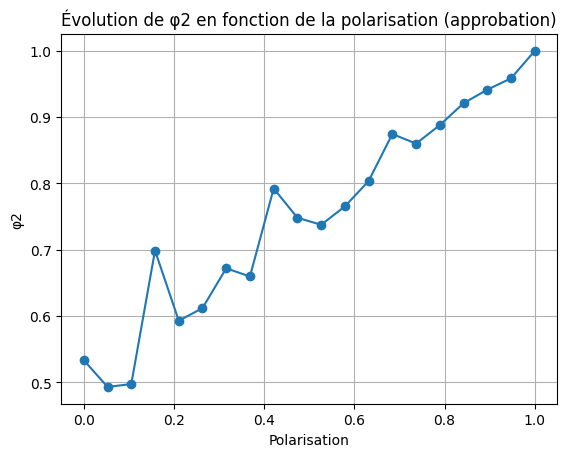

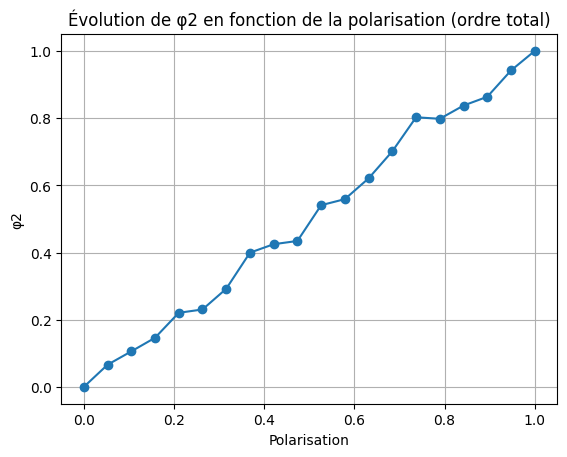

In [13]:
polarisations = np.linspace(0, 1, 20)
phi2_approbation_val = []

for pol in polarisations:
    profile = generation_profile_approbation(n=1000, m=10, polarisation=pol, p=0.1)
    phi2_approbation_val.append(phi2_approbation(profile))

plt.plot(polarisations, phi2_approbation_val, marker='o')
plt.title('Évolution de φ2 en fonction de la polarisation (approbation)')
plt.xlabel('Polarisation')
plt.ylabel('φ2')
plt.grid()
plt.show()


phi2_ordre_val = []
for pol in polarisations:
    profile = generation_profile_ordretotal(n=1000, m=10, polarisation=pol, p=0.1, scale=1, spread=1)
    phi2_ordre_val.append(phi2_ordre(profile))

plt.plot(polarisations, phi2_ordre_val, marker='o')
plt.title('Évolution de φ2 en fonction de la polarisation (ordre total)')
plt.xlabel('Polarisation')
plt.ylabel('φ2')
plt.grid()
plt.show()

Nous observons que la mesure φ₂ augmente globalement avec le niveau de polarisation. Lorsque la polarisation est faible, les profils sont homogènes et $\varphi^{2}$ est proche de 0. À mesure que la polarisation augmente, des groupes opposés apparaissent, ce qui augmente les désaccords entre paires de candidates, et donc la valeur de $\varphi^{2}$.  
On observe toutefois que la mesure n’est pas parfaitement monotone en raison du bruit introduit dans la génération des profils.

# Partie 3

Question 7 :

Soit $a_{v_k}, a_{v_l}, a_{v_j} \in A$.  
  
Montrons la positivité :   
$d_H(a_{v_k}, a_{v_l})$ est une somme de 1 et 0. On a donc bien $d_H(a_{v_k}, a_{v_l}) ≥ 0$.  
$d_S(≺_{v_k}, ≺_{v_l})$ est une somme valeur absolue. On a donc bien $d_S(≺_{v_k}, ≺_{v_l}) ≥ 0$.  
La positivité est bien respectée pour ces deux applications.  

Montrons la séparation.  
$d_H(a_{v_k}, a_{v_l}) = 0 \Leftrightarrow \sum_{i=1}^m \mathbf{1}_{a_{v_k}[i] \ne a_{v_l}[i]} = 0 \Leftrightarrow \forall i\in $ {1,...,m} : $ \mathbf{1}_{a_{v_k}[i] \ne a_{v_l}[i]} = 0 \Leftrightarrow \forall i\in $ {1,...,m} : $ a_{v_k}[i] = a_{v_l}[i] \Leftrightarrow a_{v_k} = a_{v_l}$.  
$d_S(≺_{v_k}, ≺_{v_l}) = 0 \Leftrightarrow \sum_{i=1}^m |r_{v_k}(i) - r_{v_l}(i)| = 0 \Leftrightarrow \forall i\in $ {1,...,m} : $ |r_{v_k}(i) - r_{v_l}(i)| = 0 \Leftrightarrow \forall i\in $ {1,...,m} : $ r_{v_k}(i) = r_{v_l}(i) \Leftrightarrow r_{v_k} = r_{v_l}$.  
La séparation est bien respectée pour ces deux applications.  

Montrons la symétrie.  
$d_H(a_{v_k}, a_{v_l}) = \sum_{i=1}^m \mathbf{1}_{a_{v_k}[i] \ne a_{v_l}[i]} = \sum_{i=1}^m \mathbf{1}_{a_{v_l}[i] \ne a_{v_k}[i]} = d_H(a_{v_l}, a_{v_k})$ grâce à la symétrie de l'indicatrice.  
$d_S(≺_{v_k}, ≺_{v_l}) = \sum_{i=1}^m |r_{v_k}(i) - r_{v_l}(i)| = \sum_{i=1}^m |r_{v_l}(i) - r_{v_k}(i)| = d_S(≺_{v_l}, ≺_{v_k})$ grâce à la symétrie de la valeur absolue.  
La symétrie est bien respectée pour ces deux applications.  

Montrons l'inégalité triangulaire.  
Tout d'abord, si $\mathbf{1}_{a_{v_k}[i] \ne a_{v_l}[i]} = 1$, alors :  
Si $\mathbf{1}_{a_{v_k}[i] \ne a_{v_j}[i]} = 0$ Alors $\mathbf{1}_{a_{v_j}[i] \ne a_{v_l}[i]} = 1$.  
Et si $\mathbf{1}_{a_{v_j}[i] \ne a_{v_l}[i]} = 0$ Alors $\mathbf{1}_{a_{v_k}[i] \ne a_{v_j}[i]} = 1$.  
On a donc $\mathbf{1}_{a_{v_k}[i] \ne a_{v_l}[i]} \leq \mathbf{1}_{a_{v_k}[i] \ne a_{v_j}[i]} + \mathbf{1}_{a_{v_j}[i] \ne a_{v_l}[i]}$.  

On montre alors :  
$d_H(a_{v_k}, a_{v_l}) = \sum_{i=1}^m \mathbf{1}_{a_{v_k}[i] \ne a_{v_l}[i]} \leq \sum_{i=1}^m (\mathbf{1}_{a_{v_k}[i] \ne a_{v_j}[i]} + \mathbf{1}_{a_{v_j}[i] \ne a_{v_l}[i]}) = \sum_{i=1}^m \mathbf{1}_{a_{v_k}[i] \ne a_{v_j}[i]} + \sum_{i=1}^m \mathbf{1}_{a_{v_j}[i] \ne a_{v_l}[i]} = d_H(a_{v_k}, a_{v_j}) + d_H(a_{v_j}, a_{v_l})$.  

De plus, grace à l'inégalité triangulaire de la valeure absolue :  
$d_S(≺_{v_k}, ≺_{v_l}) = \sum_{i=1}^m |r_{v_k}(i) - r_{v_l}(i)| = \sum_{i=1}^m |r_{v_k}(i) - r_{v_j}(i) + r_{v_j}(i)- r_{v_l}(i)| \leq \sum_{i=1}^m(|r_{v_k}(i) - r_{v_j}(i)| + |r_{v_j}(i)- r_{v_l}(i)|) =\sum_{i=1}^m |r_{v_k}(i) - r_{v_j}(i)| + \sum_{i=1}^m |r_{v_j}(i) - r_{v_l}(i)| = d_S(≺_{v_k}, ≺_{v_j}) + d_S(≺_{v_j}, ≺_{v_l})$.  
L'inégalité triangulaire est bien respectée pour ces deux applications.  

On conclut que ces deux applications sont des distances.

Question 8 :

In [14]:
def distance_hamming(a1, a2):
    return np.sum(np.array(a1) != np.array(a2))

def distance_spearman(s1, s2):
    rank = {c: i for i, c in enumerate(s1)}
    rank2 = {c: i for i, c in enumerate(s2)}
    return sum(abs(rank[c] - rank2[c]) for c in rank)


# Question 9 :

$\varphi_{d_H}$ vérifie les axiomes 1, 2, 3 et 4.

On rappelle que :
$$
\varphi_{d_H}(p)=\frac{2}{nm}\left(u_1^*(p)-u_2^*(p)\right)
$$

**Axiome 1 :**

On veut montrer que $\varphi_{d_H}(p)\in[0,1]$.

Déjà, on remarque que $u_2^*(p)\leq u_1^*(p)$ car si on prend $a_1=a_2=a^*$ dans la définition de $u_2^*$, on retombe sur $u_1^*$, donc le minimum sur tous les couples ne peut qu'être meilleur. Du coup $u_1^*(p)-u_2^*(p)\geq 0$, ce qui donne bien $\varphi_{d_H}(p)\geq 0$.

Pour la borne supérieure, on sait (cf. question 10) que le bulletin optimal choisit la valeur majoritaire sur chaque coordonnée, et dans le pire cas on fait $\frac{n}{2}$ erreurs par coordonnée. Donc $u_1^*(p)\leq \frac{nm}{2}$.
Comme $u_2^*(p)\geq 0$, on a :
$$
\varphi_{d_H}(p)\leq \frac{2}{nm}\times \frac{nm}{2}=1
$$

On a bien $\varphi_{d_H}(p)\in[0,1]$.

Maintenant on montre $\varphi_{d_H}(p)=0 \iff p=p_a$ :

$(\Leftarrow)$ Si $p=p_a$ alors tous les bulletins sont identiques à $a$, donc $u_1^*(p_a)=0$ (en prenant $a$) et $u_2^*(p_a)=0$ (en prenant $a_1=a_2=a$). D'où $\varphi_{d_H}(p_a)=0$.

$(\Rightarrow)$ Si $\varphi_{d_H}(p)=0$, alors $u_1^*(p)=u_2^*(p)$. Soit $a^*$ le bulletin réalisant le min de $u_1^*$. Si il existe un bulletin $a'\in p$ avec $a'\neq a^*$, alors en prenant $a_1=a^*$ et $a_2=a'$ dans $u_2^*$, le bulletin $a'$ contribue 0 au lieu de $d_H(a^*,a')>0$, et les autres bulletins contribuent au plus autant. Donc $u_2^*(p) < u_1^*(p)$, contradiction. Tous les bulletins sont donc égaux, i.e. $p=p_a$.

Ensuite on montre $\varphi_{d_H}(p)=1 \iff p=p_{a,\bar a}$ :

$(\Leftarrow)$ Soit $p_{a,\bar a}$ le profil avec $\frac{n}{2}$ copies de $a$ et $\frac{n}{2}$ copies de $\bar a$.
On a $u_2^*(p_{a,\bar a})=0$ en prenant $a_1=a$ et $a_2=\bar a$.
Pour $u_1^*$ : sur chaque coordonnée $j$, il y a exactement $\frac{n}{2}$ bulletins à 0 et $\frac{n}{2}$ à 1 (puisque $a$ et $\bar{a}$ sont opposés). Quel que soit le choix, on commet $\frac{n}{2}$ erreurs par coordonnée, donc $u_1^*(p_{a,\bar a})=\frac{nm}{2}$.
On obtient $\varphi_{d_H}(p_{a,\bar a})=\frac{2}{nm}\times\frac{nm}{2}=1$.

$(\Rightarrow)$ Si $\varphi_{d_H}(p)=1$, alors $u_1^*(p)-u_2^*(p)=\frac{nm}{2}$.
Vu que $u_1^*(p)\leq \frac{nm}{2}$ et $u_2^*(p)\geq 0$, on doit avoir $u_1^*(p)=\frac{nm}{2}$ et $u_2^*(p)=0$.

$u_2^*(p)=0$ veut dire qu'il existe $a_1,a_2$ tels que chaque bulletin $a'$ du profil est soit $a_1$ soit $a_2$ (sinon le min serait $>0$). Donc le profil contient au plus deux bulletins distincts.

$u_1^*(p)=\frac{nm}{2}$ veut dire que sur chaque coordonnée, même en prenant la valeur majoritaire, on fait $\frac{n}{2}$ erreurs. Donc il y a exactement $\frac{n}{2}$ zéros et $\frac{n}{2}$ uns sur chaque position. Comme il n'y a que deux bulletins distincts et que chaque coordonnée est à moitié 0 moitié 1, ces deux bulletins doivent être opposés. D'où $p=p_{a,\bar a}$.

$\varphi_{d_H}$ vérifie donc l'axiome 1.

**Axiome 2 :**

Soit $\pi$ une permutation sur $\{1,\dots,m\}$. Passer de $p$ à $p^\pi$ permute les coordonnées de tous les bulletins de la même façon. Or $d_H(a^\pi,b^\pi)=d_H(a,b)$ car la distance de Hamming ne dépend que du nombre de positions différentes, pas de leur indice. Donc $u_1^*$ et $u_2^*$ ne changent pas quand on permute les candidates, et $\varphi_{d_H}(p^\pi)=\varphi_{d_H}(p)$.

**Axiome 3 :**

Permuter les votantes ($\sigma p$) ne fait que réordonner les bulletins dans le profil. Les sommes dans $u_1^*$ et $u_2^*$ portent sur l'ensemble des bulletins, donc l'ordre n'importe pas. D'où $\varphi_{d_H}(\sigma p)=\varphi_{d_H}(p)$.

**Axiome 4 :**

Dans $kp$, chaque bulletin est répété $k$ fois, donc :
$$
\sum_{a'\in kp} d_H(a,a') = k\sum_{a'\in p} d_H(a,a')
$$
En prenant le min, $u_1^*(kp)=k\,u_1^*(p)$ et pareil $u_2^*(kp)=k\,u_2^*(p)$. Le profil $kp$ contient $kn$ votantes, donc :
$$
\varphi_{d_H}(kp)=\frac{2}{knm}(k\,u_1^*(p)-k\,u_2^*(p))=\frac{2}{nm}(u_1^*(p)-u_2^*(p))=\varphi_{d_H}(p)
$$

On conclut que $\varphi_{d_H}$ vérifie les 4 axiomes.

# Question 10 :

Soit $p=(a^{(1)},\dots,a^{(n)})\in \mathcal A^n$. On veut calculer $u_1^*(p)=\min_{a\in\mathcal A}\sum_{t=1}^n d_H(a,a^{(t)})$ sans parcourir les $2^m$ bulletins possibles.

L'idée c'est de remarquer qu'on peut décomposer le coût coordonnée par coordonnée :
$$
\sum_{t=1}^n d_H(a,a^{(t)})
= \sum_{t=1}^n\sum_{j=1}^m \mathbf{1}_{a[j]\neq a^{(t)}[j]}
= \sum_{j=1}^m\sum_{t=1}^n \mathbf{1}_{a[j]\neq a^{(t)}[j]}
$$

Donc on peut minimiser chaque coordonnée indépendamment. Pour une coordonnée $j$ donnée, on note $n_j^1$ le nombre de bulletins qui valent 1 en position $j$ et $n_j^0 = n - n_j^1$ ceux qui valent 0.

Si on choisit $a[j]=1$, on fait $n_j^0$ erreurs. Si on choisit $a[j]=0$, on fait $n_j^1$ erreurs. Le mieux c'est donc de prendre la valeur majoritaire, et la contribution de la coordonnée $j$ vaut $\min(n_j^0, n_j^1)$.

Au final :
$$
u_1^*(p) = \sum_{j=1}^m \min(n_j^0, n_j^1)
$$

Et le bulletin optimal $a^*$ prend simplement la valeur majoritaire sur chaque coordonnée.

Côté complexité, on parcourt les $m$ coordonnées et pour chacune on compte les 0 et les 1 parmi les $n$ bulletins, ce qui donne du $O(nm)$. C'est beaucoup mieux que de tester les $2^m$ bulletins possibles.

# Question 11 :

Soit $p=(\succ_1,\dots,\succ_n)\in \mathcal L^n$. On veut calculer $u_1^*(p)=\min_{\succ\in\mathcal L}\sum_{t=1}^n d_S(\succ,\succ_t)$.

Contrairement au cas des approbations, on ne peut pas traiter les candidates indépendamment ici, parce qu'un bulletin de consensus doit être un ordre total : si on attribue le rang $k$ à une candidate, aucune autre ne peut avoir ce rang.

On va se ramener à un problème de couplage parfait de poids minimum dans un graphe biparti.

Pour chaque candidate $c_i$ et chaque rang $k\in\{1,\dots,m\}$, on pose :
$$
w_{i,k}=\sum_{t=1}^n \left|k-r_{\succ_t}(c_i)\right|
$$
C'est le coût total si on décide de placer $c_i$ au rang $k$.

On construit un graphe biparti avec les candidates d'un côté et les rangs de l'autre, et l'arête entre $c_i$ et $k$ a pour poids $w_{i,k}$. Un couplage parfait dans ce graphe associe chaque candidate à un rang unique (et inversement), donc ça définit exactement un ordre total.

Le poids d'un couplage associé à un ordre $\succ$ vaut :
$$
\sum_{i=1}^m w_{i,r_{\succ}(c_i)} = \sum_{i=1}^m \sum_{t=1}^n |r_{\succ}(c_i)-r_{\succ_t}(c_i)| = \sum_{t=1}^n d_S(\succ,\succ_t)
$$

Donc minimiser $\sum_{t=1}^n d_S(\succ,\succ_t)$ sur $\mathcal{L}$ revient à trouver un couplage parfait de poids minimum.

En pratique, on construit la matrice de coûts $W=(w_{i,k})$ de taille $m\times m$ et on utilise `scipy.optimize.linear_sum_assignment` qui résout ce problème d'affectation.

Pour la complexité : construire $W$ coûte $O(nm^2)$ (il y a $m^2$ coefficients, chacun calculé en sommant sur $n$ votantes), et la résolution du problème d'affectation est en $O(m^3)$. Donc au total $O(nm^2 + m^3)$, ce qui est polynomial.

Question 12 :

In [15]:
from scipy.optimize import linear_sum_assignment

In [16]:
def u1_approbation(p):
    n = len(p)
    m = len(p[0])
    u1 = 0
    for j in range(m):
        n_j1 = sum(a[j] for a in p)
        n_j0 = n - n_j1
        u1 += min(n_j0, n_j1)
    return u1

def u1_ordre(p):
    m = len(p[0])

    # matrice des coûts
    W = np.zeros((m, m), dtype=int)

    ranks = []
    for a in p:
        rank = {candidate : i for i,candidate in enumerate(a)}
        ranks.append(rank)

    for i in range(m):
        for k in range(m):
            W[i,k] = sum(abs(k - rank[i]) for rank in ranks)

    # problème de couplage parfait
    row_ind, col_ind = linear_sum_assignment(W)

    return int(W[row_ind, col_ind].sum())


Question 13 :

In [ ]:
def u2_approbation(p):

    # Si tous les profils sont identiques, la distance est nulle
    if len(set(tuple(a) for a in p)) < 2:
        return 0
    
    a1 = random.choice(p) 
    a2 = random.choice([a for a in p if a != a1]) # Centroides differents


    while True :
        cluster_a1 = []
        cluster_a2 = []
        for a in p :
            if distance_hamming(a, a1) < distance_hamming(a, a2):
                cluster_a1.append(a)
            else:
                cluster_a2.append(a)
        
        # Si un cluster est vide, on arrête pour éviter les erreurs de calcul
        if not cluster_a1 or not cluster_a2:
            break

        a1_new = min(cluster_a1, key = lambda x : sum(distance_hamming(a, x) for a in cluster_a1))
        a2_new = min(cluster_a2, key = lambda x : sum(distance_hamming(a, x) for a in cluster_a2))

        if a1_new == a1 and a2_new == a2 :
            break

        a1, a2 = a1_new, a2_new

    return sum(distance_hamming(a, a1) for a in cluster_a1) + sum(distance_hamming(a, a2) for a in cluster_a2)

def u2_ordre(p):

    # Si tous les profils sont identiques, la distance est nulle
    if len(set(tuple(a) for a in p)) < 2:
        return 0
    
    a1 = random.choice(p) 
    a2 = random.choice([a for a in p if a != a1]) # Centroides differents
    

    while True :
        cluster_a1 = []
        cluster_a2 = []
        for a in p :
            if distance_spearman(a, a1) < distance_spearman(a, a2):
                cluster_a1.append(a)
            else:
                cluster_a2.append(a)

        # Si un cluster est vide, on arrête pour éviter les erreurs de calcul
        if not cluster_a1 or not cluster_a2:
            break

        a1_new = min(cluster_a1, key = lambda x : sum(distance_spearman(a, x) for a in cluster_a1))
        a2_new = min(cluster_a2, key = lambda x : sum(distance_spearman(a, x) for a in cluster_a2))

        if a1_new == a1 and a2_new == a2 :
            break

        a1, a2 = a1_new, a2_new

    return sum(distance_spearman(a, a1) for a in cluster_a1) + sum(distance_spearman(a, a2) for a in cluster_a2)


Question 14 :

In [18]:
def phi_dH(p):
    n = len(p)
    m = len(p[0])
    return (2 / (n * m)) * (u1_approbation(p) - u2_approbation(p))


def phi_dS(p):
    n = len(p)
    m = len(p[0])
    return (4 / (n * m**2)) * (u1_ordre(p) - u2_ordre(p))

Question 15 :

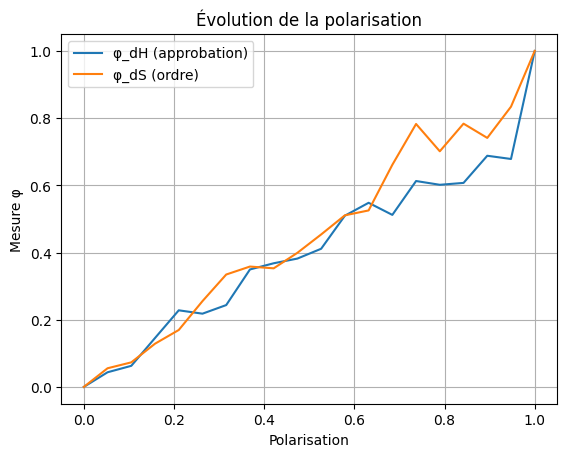

In [29]:
def experiment(n=50, m=10, nb_tests=10):
    polarisations = np.linspace(0, 1, 20)

    phi_H_vals = []
    phi_S_vals = []

    for pol in polarisations:
        phi_H_mean = 0
        phi_S_mean = 0

        for _ in range(nb_tests):
            # génération des profils
            p_H = generation_profile_approbation(n, m, pol)
            p_S = generation_profile_ordretotal(n, m, pol)

            # calculs
            phi_H_mean += phi_dH(p_H)
            phi_S_mean += phi_dS(p_S)

        phi_H_vals.append(phi_H_mean / nb_tests)
        phi_S_vals.append(phi_S_mean / nb_tests)

    # tracé
    plt.figure()
    plt.plot(polarisations, phi_H_vals, label="φ_dH (approbation)")
    plt.plot(polarisations, phi_S_vals, label="φ_dS (ordre)")
    plt.xlabel("Polarisation")
    plt.ylabel("Mesure φ")
    plt.title("Évolution de la polarisation")
    plt.legend()
    plt.grid()

    plt.show()

experiment()

### Présentation de l’expérience

Nous étudions l’évolution des mesures de polarisation  
$\varphi_{d_H}(p)$ et $\varphi_{d_S}(p)$ en fonction du paramètre de polarisation utilisé lors de la génération des profils.

Pour cela, nous faisons varier ce paramètre entre 0 et 1.  
Pour chaque valeur, plusieurs profils aléatoires sont générés, et la valeur moyenne de $\varphi$ est calculée afin de réduire l’effet de l’aléatoire.


### Résultats observés

Les courbes obtenues montrent que :

- lorsque la polarisation est faible (proche de 0), les valeurs de $\varphi$ sont proches de 0 ;
- lorsque la polarisation augmente, les valeurs de $\varphi$ augmentent également ;
- lorsque la polarisation est élevée (proche de 1), les valeurs de $\varphi$ se rapprochent de 1.


### Interprétation

Ces résultats sont cohérents avec l’interprétation de la mesure $\varphi$ :

- une valeur faible correspond à un profil proche du consensus, où les électeurs ont des préférences similaires ;
- une valeur élevée correspond à un profil fortement polarisé, où les électeurs sont divisés en groupes opposés.

Ainsi, la mesure $\varphi$ permet de capturer efficacement le niveau de polarisation d’un profil.


### Comparaison entre $d_H$ et $d_S$

On observe que les deux mesures présentent un comportement globalement similaire : elles augmentent avec le niveau de polarisation.

Cependant, de légères différences peuvent apparaître entre les courbes, dues à la nature des distances utilisées :

- la distance de Hamming considère les votes indépendamment pour chaque candidate ;
- la distance de Spearman prend en compte l’ordre global des préférences.


### Remarque

Les courbes peuvent présenter de légères fluctuations dues à l’aléa de génération des profils ainsi qu’à l’approximation utilisée pour le calcul de $\tilde{u}_2^*(p)$.


### Conclusion

Cette expérience confirme que les mesures $\varphi_{d_H}$ et $\varphi_{d_S}$ sont pertinentes pour quantifier la polarisation d’un profil électoral.

Question 9:

$\varphi_{d_H}$ vérifie les axiomes 1, 2, 3 et 4.

On rappelle que :
$$
\varphi_{d_H}(p)=\frac{2}{nm}\left(u_1^*(p)-u_2^*(p)\right)
$$

**Axiome 1 :**

On veut montrer que $\varphi_{d_H}(p)\in[0,1]$.

Déjà, on remarque que $u_2^*(p)\leq u_1^*(p)$ car si on prend $a_1=a_2=a^*$ dans la définition de $u_2^*$, on retombe sur $u_1^*$, donc le minimum sur tous les couples ne peut qu'être meilleur. Du coup $u_1^*(p)-u_2^*(p)\geq 0$, ce qui donne bien $\varphi_{d_H}(p)\geq 0$.

Pour la borne supérieure, on sait (cf. question 10) que le bulletin optimal choisit la valeur majoritaire sur chaque coordonnée, et dans le pire cas on fait $\frac{n}{2}$ erreurs par coordonnée. Donc $u_1^*(p)\leq \frac{nm}{2}$.
Comme $u_2^*(p)\geq 0$, on a :
$$
\varphi_{d_H}(p)\leq \frac{2}{nm}\times \frac{nm}{2}=1
$$

On a bien $\varphi_{d_H}(p)\in[0,1]$.

Maintenant on montre $\varphi_{d_H}(p)=0 \iff p=p_a$ :

$(\Leftarrow)$ Si $p=p_a$ alors tous les bulletins sont identiques à $a$, donc $u_1^*(p_a)=0$ (en prenant $a$) et $u_2^*(p_a)=0$ (en prenant $a_1=a_2=a$). D'où $\varphi_{d_H}(p_a)=0$.

$(\Rightarrow)$ Si $\varphi_{d_H}(p)=0$, alors $u_1^*(p)=u_2^*(p)$. Soit $a^*$ le bulletin réalisant le min de $u_1^*$. Si il existe un bulletin $a'\in p$ avec $a'\neq a^*$, alors en prenant $a_1=a^*$ et $a_2=a'$ dans $u_2^*$, le bulletin $a'$ contribue 0 au lieu de $d_H(a^*,a')>0$, et les autres bulletins contribuent au plus autant. Donc $u_2^*(p) < u_1^*(p)$, contradiction. Tous les bulletins sont donc égaux, i.e. $p=p_a$.

Ensuite on montre $\varphi_{d_H}(p)=1 \iff p=p_{a,\bar a}$ :

$(\Leftarrow)$ Soit $p_{a,\bar a}$ le profil avec $\frac{n}{2}$ copies de $a$ et $\frac{n}{2}$ copies de $\bar a$.
On a $u_2^*(p_{a,\bar a})=0$ en prenant $a_1=a$ et $a_2=\bar a$.
Pour $u_1^*$ : sur chaque coordonnée $j$, il y a exactement $\frac{n}{2}$ bulletins à 0 et $\frac{n}{2}$ à 1 (puisque $a$ et $\bar{a}$ sont opposés). Quel que soit le choix, on commet $\frac{n}{2}$ erreurs par coordonnée, donc $u_1^*(p_{a,\bar a})=\frac{nm}{2}$.
On obtient $\varphi_{d_H}(p_{a,\bar a})=\frac{2}{nm}\times\frac{nm}{2}=1$.

$(\Rightarrow)$ Si $\varphi_{d_H}(p)=1$, alors $u_1^*(p)-u_2^*(p)=\frac{nm}{2}$.
Vu que $u_1^*(p)\leq \frac{nm}{2}$ et $u_2^*(p)\geq 0$, on doit avoir $u_1^*(p)=\frac{nm}{2}$ et $u_2^*(p)=0$.

$u_2^*(p)=0$ veut dire qu'il existe $a_1,a_2$ tels que chaque bulletin $a'$ du profil est soit $a_1$ soit $a_2$ (sinon le min serait $>0$). Donc le profil contient au plus deux bulletins distincts.

$u_1^*(p)=\frac{nm}{2}$ veut dire que sur chaque coordonnée, même en prenant la valeur majoritaire, on fait $\frac{n}{2}$ erreurs. Donc il y a exactement $\frac{n}{2}$ zéros et $\frac{n}{2}$ uns sur chaque position. Comme il n'y a que deux bulletins distincts et que chaque coordonnée est à moitié 0 moitié 1, ces deux bulletins doivent être opposés. D'où $p=p_{a,\bar a}$.

$\varphi_{d_H}$ vérifie donc l'axiome 1.

**Axiome 2 :**

Soit $\pi$ une permutation sur $\{1,\dots,m\}$. Passer de $p$ à $p^\pi$ permute les coordonnées de tous les bulletins de la même façon. Or $d_H(a^\pi,b^\pi)=d_H(a,b)$ car la distance de Hamming ne dépend que du nombre de positions différentes, pas de leur indice. Donc $u_1^*$ et $u_2^*$ ne changent pas quand on permute les candidates, et $\varphi_{d_H}(p^\pi)=\varphi_{d_H}(p)$.

**Axiome 3 :**

Permuter les votantes ($\sigma p$) ne fait que réordonner les bulletins dans le profil. Les sommes dans $u_1^*$ et $u_2^*$ portent sur l'ensemble des bulletins, donc l'ordre n'importe pas. D'où $\varphi_{d_H}(\sigma p)=\varphi_{d_H}(p)$.

**Axiome 4 :**

Dans $kp$, chaque bulletin est répété $k$ fois, donc :
$$
\sum_{a'\in kp} d_H(a,a') = k\sum_{a'\in p} d_H(a,a')
$$
En prenant le min, $u_1^*(kp)=k\,u_1^*(p)$ et pareil $u_2^*(kp)=k\,u_2^*(p)$. Le profil $kp$ contient $kn$ votantes, donc :
$$
\varphi_{d_H}(kp)=\frac{2}{knm}(k\,u_1^*(p)-k\,u_2^*(p))=\frac{2}{nm}(u_1^*(p)-u_2^*(p))=\varphi_{d_H}(p)
$$

On conclut que $\varphi_{d_H}$ vérifie les 4 axiomes.

In [ ]:
#proposition de correction Q13

## NOUVELLE FONCTION : centroide_approbation
## POURQUOI : dans l'ancien code, on cherchait le centroïde parmi les bulletins existants du cluster
## (c'est du k-medoids). Le sujet demande de chercher dans tout A (c'est du k-means).
## Le sujet dit explicitement "utiliser votre réponse à la question 12" pour cette étape.
## La réponse Q10/Q12 nous dit que le bulletin optimal pour un groupe = vote majoritaire coord par coord.

def centroide_approbation(cluster):
    n = len(cluster)
    m = len(cluster[0])
    centroide = []
    for j in range(m):
        # on compte combien de bulletins du cluster valent 1 en position j
        n_j1 = sum(a[j] for a in cluster)
        # on prend la valeur majoritaire (comme dans u1_approbation)
        if n_j1 >= n - n_j1:
            centroide.append(1)
        else:
            centroide.append(0)
    return centroide


## NOUVELLE FONCTION : centroide_ordre
## POURQUOI : même raison, l'ancien code cherchait parmi les bulletins existants.
## Pour les ordres totaux, le bulletin optimal se calcule par couplage parfait (cf Q11/Q12).

def centroide_ordre(cluster):
    m = len(cluster[0])

    # on construit les rangs de chaque votante du cluster
    ranks = []
    for a in cluster:
        rank = {candidate: i for i, candidate in enumerate(a)}
        ranks.append(rank)

    # matrice de coûts W[i,k] = coût de placer la candidate i au rang k
    # (exactement comme dans u1_ordre)
    W = np.zeros((m, m), dtype=int)
    for i in range(m):
        for k in range(m):
            W[i, k] = sum(abs(k - rank[i]) for rank in ranks)

    # résolution du problème d'affectation
    row_ind, col_ind = linear_sum_assignment(W)

    # CHANGEMENT : on doit reconstruire l'ordre total à partir du résultat
    # col_ind[i] = le rang attribué à la candidate i
    # donc ordre[rang] = candidate, ce qui correspond à notre format de profil
    ordre = [0] * m
    for i in range(m):
        ordre[col_ind[i]] = i
    return ordre


def u2_approbation(p, nb_restarts=20):
    ## CHANGEMENT : ajout du paramètre nb_restarts
    ## POURQUOI : le sujet dit "relancer l'algorithme plusieurs fois"
    ## et garder le minimum, car k-means converge vers un optimum local

    if len(set(tuple(a) for a in p)) < 2:
        return 0

    best = float('inf')  ## on garde le meilleur résultat sur tous les essais

    for _ in range(nb_restarts):  ## CHANGEMENT : boucle de relance (avant on faisait qu'un seul essai)
        a1 = random.choice(p).copy()
        a2 = random.choice([a for a in p if a != a1]).copy()

        cluster_a1 = []
        cluster_a2 = []

        while True:
            cluster_a1 = []
            cluster_a2 = []
            for a in p:
                ## CHANGEMENT : <= au lieu de <
                ## POURQUOI : l'algo du sujet dit "cluster(ai) = 1 si dH(ai, a1) <= dH(ai, a2)"
                ## avant on avait < ce qui envoyait les égalités dans le mauvais cluster
                if distance_hamming(a, a1) <= distance_hamming(a, a2):
                    cluster_a1.append(a)
                else:
                    cluster_a2.append(a)

            if not cluster_a1 or not cluster_a2:
                break

            ## CHANGEMENT PRINCIPAL : on utilise centroide_approbation au lieu de min(cluster, ...)
            ## AVANT : a1_new = min(cluster_a1, key=lambda x: sum(distance_hamming(a, x) for a in cluster_a1))
            ##   -> ça cherchait le meilleur bulletin PARMI ceux du cluster (k-medoids)
            ## MAINTENANT : on calcule le vote majoritaire coord par coord (k-means, cf Q12)
            ##   -> ça cherche le meilleur bulletin dans TOUT l'espace A
            a1_new = centroide_approbation(cluster_a1)
            a2_new = centroide_approbation(cluster_a2)

            if a1_new == a1 and a2_new == a2:
                break

            a1, a2 = a1_new, a2_new

        if cluster_a1 and cluster_a2:
            val = sum(distance_hamming(a, a1) for a in cluster_a1) + sum(distance_hamming(a, a2) for a in cluster_a2)
            best = min(best, val)  ## CHANGEMENT : on garde le min sur toutes les relances

    return best


def u2_ordre(p, nb_restarts=20):
    ## même structure que u2_approbation, mêmes changements

    if len(set(tuple(a) for a in p)) < 2:
        return 0

    best = float('inf')

    for _ in range(nb_restarts):
        a1 = random.choice(p).copy()
        a2 = random.choice([a for a in p if a != a1]).copy()

        cluster_a1 = []
        cluster_a2 = []

        while True:
            cluster_a1 = []
            cluster_a2 = []
            for a in p:
                ## <= au lieu de <
                if distance_spearman(a, a1) <= distance_spearman(a, a2):
                    cluster_a1.append(a)
                else:
                    cluster_a2.append(a)

            if not cluster_a1 or not cluster_a2:
                break

            ## CHANGEMENT : couplage parfait (cf Q12) au lieu de chercher parmi les bulletins
            a1_new = centroide_ordre(cluster_a1)
            a2_new = centroide_ordre(cluster_a2)

            if a1_new == a1 and a2_new == a2:
                break

            a1, a2 = a1_new, a2_new

        if cluster_a1 and cluster_a2:
            val = sum(distance_spearman(a, a1) for a in cluster_a1) + sum(distance_spearman(a, a2) for a in cluster_a2)
            best = min(best, val)

    return best